# Face detection 02 — HOG + SVM a confronto con YuNet (rete neurale leggera)

Nel notebook 01 il rilevatore classico **HOG + SVM** è stato corretto e misurato su WIDER FACE.
Qui lo confrontiamo, **sulle stesse 300 immagini e con lo stesso protocollo**, con **YuNet** (Wu et al., 2023):
una rete convoluzionale per face detection distribuita con OpenCV, pensata proprio per dispositivi con poche risorse
(~75 mila parametri, file da 230 KB).

Domanda per il caso *ProCam* (fotocamera con hardware limitato): **quanto costa, e quanto rende, passare a un piccolo modello
di deep learning?**

In [1]:
import os, json, time, zipfile, urllib.request
import numpy as np
import cv2
import matplotlib.pyplot as plt
import joblib
from skimage.feature import hog

DATA_DIR     = '/content/wider_face'
HOG_FOLDER   = '/content/drive/MyDrive/modelli_addestrati/face_detection_hog_svm'
OUT_FOLDER   = '/content/drive/MyDrive/modelli_addestrati/face_detection_confronto'
HF_REPO      = 'CUHK-CSE/wider_face'
YUNET_URL    = ('https://media.githubusercontent.com/media/opencv/opencv_zoo/main/models/'
                'face_detection_yunet/face_detection_yunet_2023mar.onnx')
YUNET_PATH   = '/content/face_detection_yunet_2023mar.onnx'

try:
    from google.colab import drive
    IN_COLAB = True
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
except ImportError:
    IN_COLAB = False

Mounted at /content/drive


In [2]:
cfg = json.load(open(os.path.join(HOG_FOLDER, 'config.json')))
res_hog_saved = json.load(open(os.path.join(HOG_FOLDER, 'risultati_val.json')))
hog_model = joblib.load(os.path.join(HOG_FOLDER, 'hog_svm_pipeline.joblib'))
PATCH, CELL, WORK_W, SCALE, STEP, NMS_IOU = (cfg[k] for k in ['PATCH', 'CELL', 'WORK_W', 'SCALE', 'STEP', 'NMS_IOU'])
BLOCKS = PATCH // CELL - 1
print('OpenCV', cv2.__version__, '| soglia HOG+SVM:', round(cfg['score_threshold'], 3))

OpenCV 5.0.0 | soglia HOG+SVM: 1.134


## 1. Dati (stesse immagini di validation del notebook 01)

In [3]:
def download_wider(data_dir=DATA_DIR):
    from huggingface_hub import hf_hub_download
    os.makedirs(data_dir, exist_ok=True)
    for name in ['wider_face_split.zip', 'WIDER_val.zip']:
        if not os.path.exists(os.path.join(data_dir, name.replace('.zip', ''))):
            with zipfile.ZipFile(hf_hub_download(HF_REPO, f'data/{name}', repo_type='dataset')) as z:
                z.extractall(data_dir)

def read_annotations(split):
    path = os.path.join(DATA_DIR, 'wider_face_split', f'wider_face_{split}_bbx_gt.txt')
    ann, lines, i = {}, open(path).read().split('\n'), 0
    while i < len(lines) and lines[i].strip():
        name, n = lines[i].strip(), int(lines[i + 1]); i += 2
        rows = [list(map(int, lines[i + k].split()[:10])) for k in range(max(n, 1))]
        i += max(n, 1)
        ann[os.path.join(DATA_DIR, f'WIDER_{split}', 'images', name)] = np.array(rows[:n] if n else [], dtype=int).reshape(-1, 10)
    return ann

download_wider()
ann_val = read_annotations('val')
val_imgs = [os.path.join(DATA_DIR, p) for p in res_hog_saved['val_images']]
print(f'{len(val_imgs)} immagini di validation')

data/wider_face_split.zip: reconstructing file:   0%|          |  0.00B / 3.59MB            

data/wider_face_split.zip: downloading bytes:           |  0.00B            

data/WIDER_val.zip: reconstructing file:   0%|          |  0.00B /  363MB            

data/WIDER_val.zip: downloading bytes:           |  0.00B            

300 immagini di validation


## 2. Protocollo di valutazione (identico al notebook 01)
IoU ≥ 0.5; i volti più piccoli della finestra minima di HOG + SVM sono **ignorati per entrambi i rilevatori**,
così il confronto riguarda solo i volti che entrambi potrebbero trovare.

In [4]:
def iou(a, b):
    xa, ya, xb, yb = max(a[0], b[0]), max(a[1], b[1]), min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, xb - xa) * max(0, yb - ya)
    return inter / float((a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter + 1e-9)

def split_gt(rows, img_w):
    min_side = PATCH * img_w / WORK_W
    boxes = [(x, y, x + w, y + h) for x, y, w, h in rows[:, :4]]
    valid = (rows[:, 2] >= min_side) & (rows[:, 3] >= min_side) & (rows[:, 7] == 0) if len(rows) else np.array([], bool)
    return [b for b, v in zip(boxes, valid) if v], [b for b, v in zip(boxes, valid) if not v]

def evaluate(all_dets, all_gt, iou_thr=0.5):
    records, n_gt = [], sum(len(g[0]) for g in all_gt.values())
    for img, dets in all_dets.items():
        gt, ign = all_gt[img]; used = [False] * len(gt)
        for d in sorted(dets, key=lambda d: d[4], reverse=True):
            ious = [iou(d, g) for g in gt]
            j = int(np.argmax(ious)) if ious else -1
            if j >= 0 and ious[j] >= iou_thr and not used[j]:
                used[j] = True; records.append((d[4], 1))
            elif any(iou(d, g) >= iou_thr for g in ign):
                continue
            else:
                records.append((d[4], 0))
    records.sort(key=lambda r: r[0], reverse=True)
    tp = np.cumsum([r[1] for r in records]); fp = np.cumsum([1 - r[1] for r in records])
    recall = tp / max(n_gt, 1); precision = tp / np.maximum(tp + fp, 1)
    prec_env = np.maximum.accumulate(precision[::-1])[::-1] if len(precision) else precision
    ap = float(np.sum(np.diff(np.concatenate([[0], recall])) * prec_env)) if len(recall) else 0.0
    return {'AP': ap, 'precision': precision, 'recall': recall, 'scores': np.array([r[0] for r in records]), 'n_gt': n_gt}

def at_threshold(all_dets, all_gt, thr):
    r = evaluate({k: [d for d in v if d[4] >= thr] for k, v in all_dets.items()}, all_gt)
    return (float(r['precision'][-1]), float(r['recall'][-1])) if len(r['recall']) else (0.0, 0.0)

## 3. I due rilevatori

In [5]:
# --- HOG + SVM (stesso codice del notebook 01) ---
def _hog_blocks(gray):
    return hog(gray, orientations=9, pixels_per_cell=(CELL, CELL), cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=False)

def hog_windows(gray):
    H = _hog_blocks(gray); s = STEP // CELL
    rows, cols = range(0, H.shape[0] - BLOCKS + 1, s), range(0, H.shape[1] - BLOCKS + 1, s)
    return (np.array([H[r:r + BLOCKS, c:c + BLOCKS].ravel() for r in rows for c in cols]),
            np.array([(c * CELL, r * CELL) for r in rows for c in cols]))

def nms(dets, thr=NMS_IOU):
    dets = sorted(dets, key=lambda d: d[4], reverse=True); keep = []
    while dets:
        cur = dets.pop(0); keep.append(cur); dets = [d for d in dets if iou(cur, d) < thr]
    return keep

def detect_hog(img_bgr, score_thr=-0.5):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY); h0, w0 = gray.shape; scale0 = w0 / WORK_W
    img = cv2.resize(gray, (WORK_W, int(round(h0 / scale0))), interpolation=cv2.INTER_AREA)
    dets, ls = [], 1.0
    while img.shape[0] >= PATCH and img.shape[1] >= PATCH:
        feats, xy = hog_windows(img)
        if len(feats):
            sc = hog_model.decision_function(feats); f = scale0 * ls; keep = sc > score_thr
            dets += [(x * f, y * f, (x + PATCH) * f, (y + PATCH) * f, float(s)) for (x, y), s in zip(xy[keep], sc[keep])]
        ls *= SCALE
        img = cv2.resize(img, (int(img.shape[1] / SCALE), int(img.shape[0] / SCALE)), interpolation=cv2.INTER_AREA)
    return nms(dets)

# --- YuNet ---
if not os.path.exists(YUNET_PATH):
    urllib.request.urlretrieve(YUNET_URL, YUNET_PATH)
print(f'YuNet: {os.path.getsize(YUNET_PATH)/1024:.0f} KB')
yunet = cv2.FaceDetectorYN.create(YUNET_PATH, '', (320, 320), score_threshold=0.3, nms_threshold=NMS_IOU, top_k=5000)

def detect_yunet(img_bgr, work_w=WORK_W):
    # stessa larghezza di lavoro di HOG + SVM, per un confronto a parità di risoluzione
    h0, w0 = img_bgr.shape[:2]; s = w0 / work_w
    img = cv2.resize(img_bgr, (work_w, int(round(h0 / s))))
    yunet.setInputSize((img.shape[1], img.shape[0]))
    _, faces = yunet.detect(img)
    if faces is None: return []
    return [(x * s, y * s, (x + w) * s, (y + h) * s, float(f[-1])) for f in faces for x, y, w, h in [f[:4]]]

YuNet: 227 KB


## 4. Valutazione

,AP@0.5,precisione,recall,ms per immagine (CPU),dimensione modello
rilevatore,,,,,
HOG + SVM,0.263,0.261,0.427,3134,9.9 MB
YuNet,0.889,0.623,0.887,54,233 KB


Volti valutati: 363 su 300 immagini


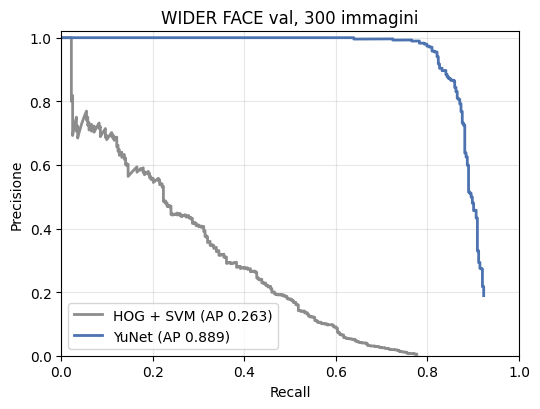

In [6]:
results = {}
for name, fn in [('HOG + SVM', detect_hog), ('YuNet', detect_yunet)]:
    dets, gts, t0 = {}, {}, time.time()
    for p in val_imgs:
        img = cv2.imread(p); dets[p] = fn(img); gts[p] = split_gt(ann_val[p], img.shape[1])
    sec = (time.time() - t0) / len(val_imgs)
    results[name] = {'dets': dets, 'gts': gts, 'eval': evaluate(dets, gts), 'sec': sec}

thr = {'HOG + SVM': cfg['score_threshold'], 'YuNet': 0.6}       # 0.6 = soglia consigliata da OpenCV per YuNet
rows = []
for name, r in results.items():
    p, rc = at_threshold(r['dets'], r['gts'], thr[name])
    rows.append({'rilevatore': name, 'AP@0.5': r['eval']['AP'], 'precisione': p, 'recall': rc,
                 'ms per immagine (CPU)': 1000 * r['sec'],
                 'dimensione modello': f"{os.path.getsize(os.path.join(HOG_FOLDER, 'hog_svm_pipeline.joblib'))/1e6:.1f} MB" if name == 'HOG + SVM' else f'{os.path.getsize(YUNET_PATH)/1e3:.0f} KB'})
import pandas as pd
comp = pd.DataFrame(rows).set_index('rilevatore')
display(comp.style.format({'AP@0.5': '{:.3f}', 'precisione': '{:.3f}', 'recall': '{:.3f}', 'ms per immagine (CPU)': '{:.0f}'}))
print(f"Volti valutati: {results['YuNet']['eval']['n_gt']:,} su {len(val_imgs)} immagini")

plt.figure(figsize=(5.5, 4.2))
for name, color in [('HOG + SVM', '#8C8C8C'), ('YuNet', '#4C72B0')]:
    e = results[name]['eval']
    plt.plot(e['recall'], e['precision'], color=color, lw=2, label=f"{name} (AP {e['AP']:.3f})")
plt.xlabel('Recall'); plt.ylabel('Precisione'); plt.title('WIDER FACE val, 300 immagini')
plt.xlim(0, 1); plt.ylim(0, 1.02); plt.grid(alpha=.3); plt.legend(); plt.tight_layout()
os.makedirs(OUT_FOLDER if IN_COLAB else '/tmp/face_cmp', exist_ok=True)
out = OUT_FOLDER if IN_COLAB else '/tmp/face_cmp'
plt.savefig(os.path.join(out, 'curva_pr.png'), dpi=160); plt.show()

## 5. Esempi a confronto

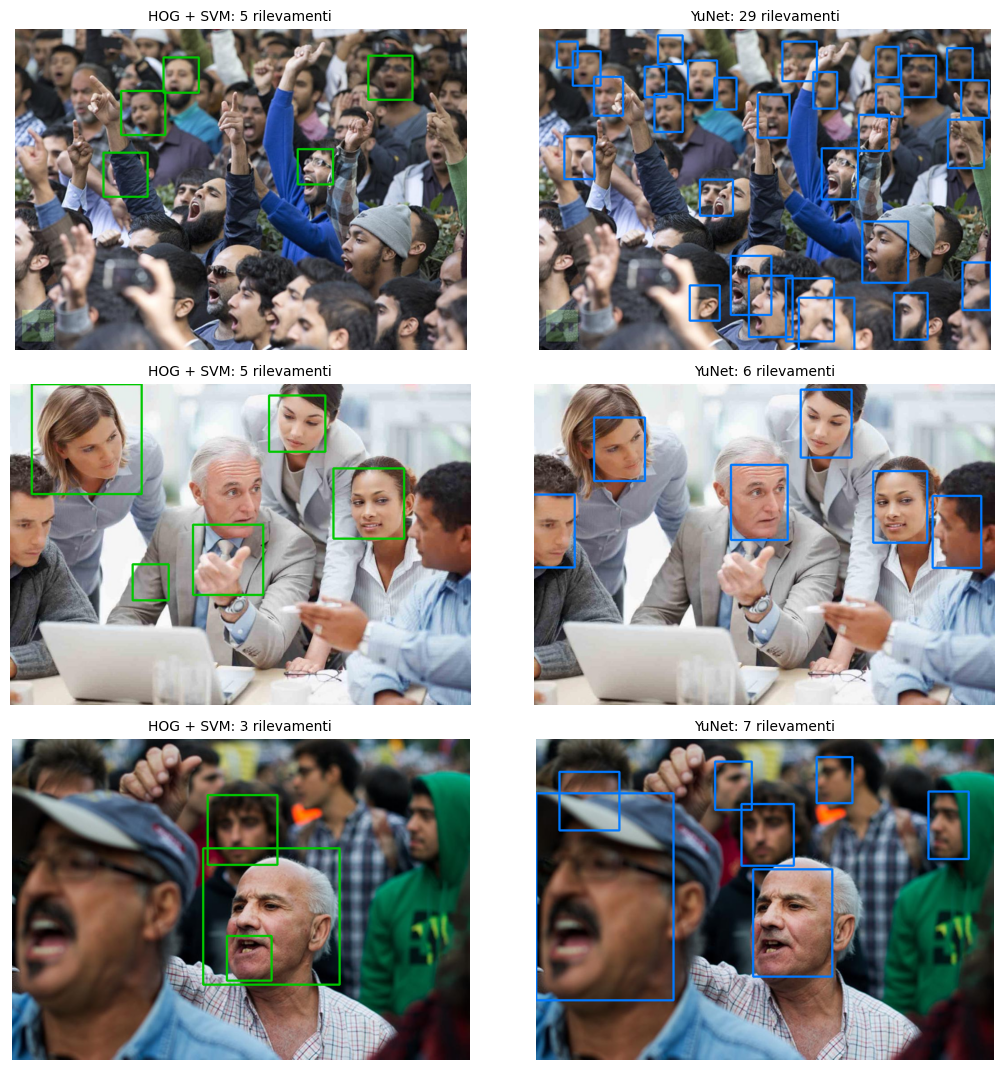

In [7]:
def draw(img, dets, color):
    vis = img.copy()
    for x1, y1, x2, y2, s in dets:
        cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), color, max(2, img.shape[1] // 300))
    return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

# immagini con più volti valutabili, per vedere le differenze
examples = sorted(val_imgs, key=lambda p: -len(results['YuNet']['gts'][p][0]))[:3]
fig, axes = plt.subplots(len(examples), 2, figsize=(11, 3.6 * len(examples)))
for row, p in zip(np.atleast_2d(axes), examples):
    img = cv2.imread(p)
    for ax, name, color in [(row[0], 'HOG + SVM', (0, 200, 0)), (row[1], 'YuNet', (255, 120, 0))]:
        d = [x for x in results[name]['dets'][p] if x[4] >= thr[name]]
        ax.imshow(draw(img, d, color)); ax.axis('off'); ax.set_title(f'{name}: {len(d)} rilevamenti', fontsize=10)
plt.tight_layout(); plt.show()

In [8]:
comp.to_csv(os.path.join(out, 'confronto_hog_yunet.csv'))
print('Salvato in', out, '→', sorted(os.listdir(out)))

Salvato in /content/drive/MyDrive/modelli_addestrati/face_detection_confronto → ['confronto_hog_yunet.csv', 'curva_pr.png']


## 6. Conclusioni

| | HOG + SVM | YuNet |
|---|---|---|
| AP@0.5 | 0.263 | **0.889** |
| Precisione (soglia operativa) | 0.26 | 0.62 |
| Recall (soglia operativa) | 0.43 | **0.89** |
| Tempo per immagine, CPU | 3134 ms | **54 ms** |
| Dimensione del modello | 9.9 MB | **233 KB** |

**YuNet è migliore su tutti i fronti**: AP più che triplicata, ~58 volte più veloce, file ~40 volte più piccolo.
Per il caso ProCam la risposta è netta: sull'hardware limitato una piccola CNN costa *meno* del rilevatore classico, non di più.
HOG + SVM paga la finestra scorrevole su una piramide di scale (decine di migliaia di valutazioni per immagine), mentre YuNet
produce tutti i riquadri in un solo passaggio.

Negli esempi si vede la differenza qualitativa: nella folla HOG trova 5 volti, YuNet 29; HOG genera riquadri su mani e giacche,
YuNet trova anche volti di profilo e parzialmente coperti.

**Nota sulla precisione di YuNet (0.62).** Molti dei suoi "falsi positivi" sono volti reali non annotati o marcati come non valutabili
in WIDER FACE (folla, sfocatura): la precisione reale è verosimilmente più alta. L'AP, che considera l'intera curva, è la metrica più affidabile.

**Lezione.** Il lavoro sul notebook 01 non è sprecato: correggere HOG + SVM e misurarlo con un protocollo onesto è ciò che rende
questo confronto credibile. Scegliere il modello giusto richiede prima una baseline misurata bene.